In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
# Define the list of rivers
rivers = ["Aysen", "Cisnes", "Palena", "Puelo", "Yelcho"]
# X11342001
# X11147001
# X11040001
# X10523002
# X10704002
river_xnames = {"Aysen":  "X11342001",
                "Cisnes": "X11147001",
                "Palena": "X11040001",
                "Puelo":  "X10523002",
                "Yelcho": "X10704002"}
river_xnamesl = [river_xnames[r] for r in rivers]

# Define the paths
upstream_model_path = "../../../data/streamflow/vic_flow/q_sim_PMET.xlsx"
downstream_model_path = "../../../data/streamflow/vic_flow/q_sim_water_sampling.xlsx"
scaling_path = "../../../data/streamflow/scaling_validation"

# actual observations only:
#upstreamobserved_path = "../observed_gauge_flow/compiled_gauge_flow_raw/compiled_gauge_flow_raw.csv"

#franken_flow option (filled in gaps) 
# Note (as of Mar 17, 2025): the output file path does not seem to be in use anymore.
upstreamobserved_path = "../../../data/streamflow/franken_flow/franken_flow.csv"
output_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers"

In [3]:
#save_est = "separate"
save_est=True
drop_Feb29 = False

In [4]:
up_obs = pd.read_csv(upstreamobserved_path)
up_obs.set_index("Date", inplace=True)
up_obs.index = pd.to_datetime(up_obs.index)
up_obs

,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,
1980-01-01,NaN,NaN,NaN,553.000,NaN
1980-01-02,NaN,NaN,NaN,532.000,NaN
1980-01-03,NaN,NaN,NaN,524.000,NaN
1980-01-04,NaN,NaN,NaN,521.000,NaN
1980-01-05,NaN,NaN,NaN,498.000,NaN
...,...,...,...,...,...
2024-01-27,323.825,210.156,652.082,403.208,326.358
2024-01-28,275.732,119.572,593.801,406.450,251.468
2024-01-29,242.560,91.519,504.260,380.047,287.128


In [5]:
upmodel = pd.read_excel(upstream_model_path)[river_xnamesl+["Unnamed: 0"]]
upmodel.columns = rivers + ["Date"]
upmodel.set_index("Date", inplace=True)
###### Chatgpt troubleshooting until next ###
upmodel.index = pd.to_datetime(upmodel.index)
##### end Chatgpt troubleshooting
upmodel

,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,
1980-01-01,0.12,65.74,0.09,48.54,47.48
1980-01-02,0.37,53.63,0.29,2.61,2.55
1980-01-03,0.68,42.57,0.54,8.18,8.00
1980-01-04,1.05,7.21,0.86,13.02,12.74
1980-01-05,1.46,19.04,1.23,10.51,10.28
...,...,...,...,...,...
2020-12-27,244.27,87.95,374.15,421.92,349.56
2020-12-28,239.43,82.01,330.93,418.31,346.57
2020-12-29,406.48,96.30,488.51,446.83,365.65


In [6]:
downmodel = pd.read_excel(downstream_model_path)
downmodel.set_index("Unnamed: 0", inplace=True)
downmodel.index.name = "Date"

### insert chatgpt
downmodel.index = pd.to_datetime(downmodel.index)
#### end chatgpt

downmodel

,Puelo,Yelcho,Palena,Cisnes,Aysen
Date,,,,,
1980-01-01,48.87,62.76,0.12,0.14,0.12
1980-01-02,2.63,3.39,0.39,0.44,0.40
1980-01-03,8.23,10.61,0.73,0.75,0.73
1980-01-04,13.11,16.91,1.12,1.08,1.12
1980-01-05,10.58,13.65,1.57,1.42,1.56
...,...,...,...,...,...
2020-12-27,424.34,532.56,455.14,106.08,295.03
2020-12-28,420.71,522.68,405.02,102.45,289.30
2020-12-29,449.71,564.57,587.78,438.55,491.03


In [7]:
ratio = downmodel / upmodel # columns and index matches up 100% i believe

# drop leap day if needed - do we need to do this with upmodel and downmodel?
if drop_Feb29:
    ratio = ratio[(ratio.index.month != 2) | (ratio.index.day != 29)]

### insert chatgpt
# Ensure the index is a DatetimeIndex
if not isinstance(ratio.index, pd.DatetimeIndex):
    ratio.index = pd.to_datetime(ratio.index)
### end chatgpt

#######THIS IS WHERE YOU DEFINE HOW MUCH OF THE MODELED DATA TO DROP

# Define the cutoff date
cutoff_date = "1990-01-01"

#TEST different cutoff date

# Define the cutoff date
#cutoff_date = "2018-01-01"

# Remove all entries in the ratio DataFrame up until the cutoff date
ratio_filtered = ratio[ratio.index >= cutoff_date]

# average out by day of year (julian date)
jul_ratio = ratio_filtered.groupby(ratio_filtered.index.dayofyear).mean()
display(ratio_filtered)
display(jul_ratio)

,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,
1990-01-01,1.128471,0.654358,1.202604,1.009371,1.733453
1990-01-02,1.138119,0.807479,1.222375,1.009401,1.678163
1990-01-03,1.140692,0.812865,1.223519,1.007703,1.624087
1990-01-04,1.147839,0.753261,1.228945,1.007692,1.567162
1990-01-05,1.150226,0.728598,1.232566,1.007733,1.532724
...,...,...,...,...,...
2020-12-27,1.207803,1.206140,1.216464,1.005736,1.523515
2020-12-28,1.208286,1.249238,1.223884,1.005737,1.508151
2020-12-29,1.208005,4.553998,1.203210,1.006445,1.544018


,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,
1,1.154268,2.609241,1.163394,1.007455,1.657684
2,1.148737,2.499139,1.170907,1.007348,1.630503
3,1.147195,2.355226,1.169367,1.007382,1.623172
4,1.154861,2.380746,1.166611,1.007402,1.620210
5,1.156145,2.644946,1.173937,1.007495,1.644190
...,...,...,...,...,...
362,1.163272,3.216551,1.167159,1.007665,1.696383
363,1.157339,3.044662,1.166421,1.007543,1.691056
364,1.154199,3.000926,1.165248,1.007670,1.655405


In [8]:
jul_ratio[(jul_ratio < 1)].dropna()

,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,


In [9]:
### Sanity check

#ratio_filtered['Cisnes'].max()

In [10]:
##### New code as of March 17, 2025
##### Apply two-sided rolling average to scaling factors to 

# Define rolling window size (e.g., 7-day average)
window_size = 60

# Extend data by wrapping around
jul_ratio_wrap = pd.concat([jul_ratio.tail(window_size), jul_ratio, jul_ratio.head(window_size)])

# Apply rolling mean
jul_ratio_rolling_wrap = jul_ratio_wrap.rolling(window=window_size, center=True).mean()

# Trim back to original length
jul_ratio_rolling = jul_ratio_rolling_wrap.iloc[window_size:-window_size].reset_index(drop=True)

In [11]:
### New alternative to above block for rolling average scaling

# make a version of jul_ratio that repeats across the whole test date range
ratio_rep = jul_ratio_rolling.reindex(up_obs.index.dayofyear) # reindex could be inefficent
ratio_rep.index = up_obs.index
down_pred = ratio_rep * up_obs#.reset_index(drop=True) # so that the numeric indices match up
#down_pred.index = up_obs.index # bring back date index
down_pred.head(3)

,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,
1980-01-01,NaN,NaN,NaN,557.076882,NaN
1980-01-02,NaN,NaN,NaN,535.935475,NaN
1980-01-03,NaN,NaN,NaN,527.890422,NaN


In [12]:
if save_est:
    if save_est=="separate":
        for col in down_pred:
            down_pred[col].rename("Q").to_frame().to_csv(
                f"../output (downstream)/{col} Flow.csv")
    else:
        down_pred.to_csv(f"{output_path}_rolling{window_size}.csv")
        #down_pred.to_csv("Downstream_Estimate_All_Rivers.csv") #Uncomment if the not-rolling version is needed
        ratio.to_csv(f"{scaling_path}/VIC_scaling_factors_allyears.csv")
        jul_ratio.to_csv(f"{scaling_path}/VIC_mean_annual_scaling_factors.csv")
        jul_ratio_rolling.to_csv(f"{scaling_path}/VIC_mean_annual_scaling_factors_rolling{window_size}.csv")

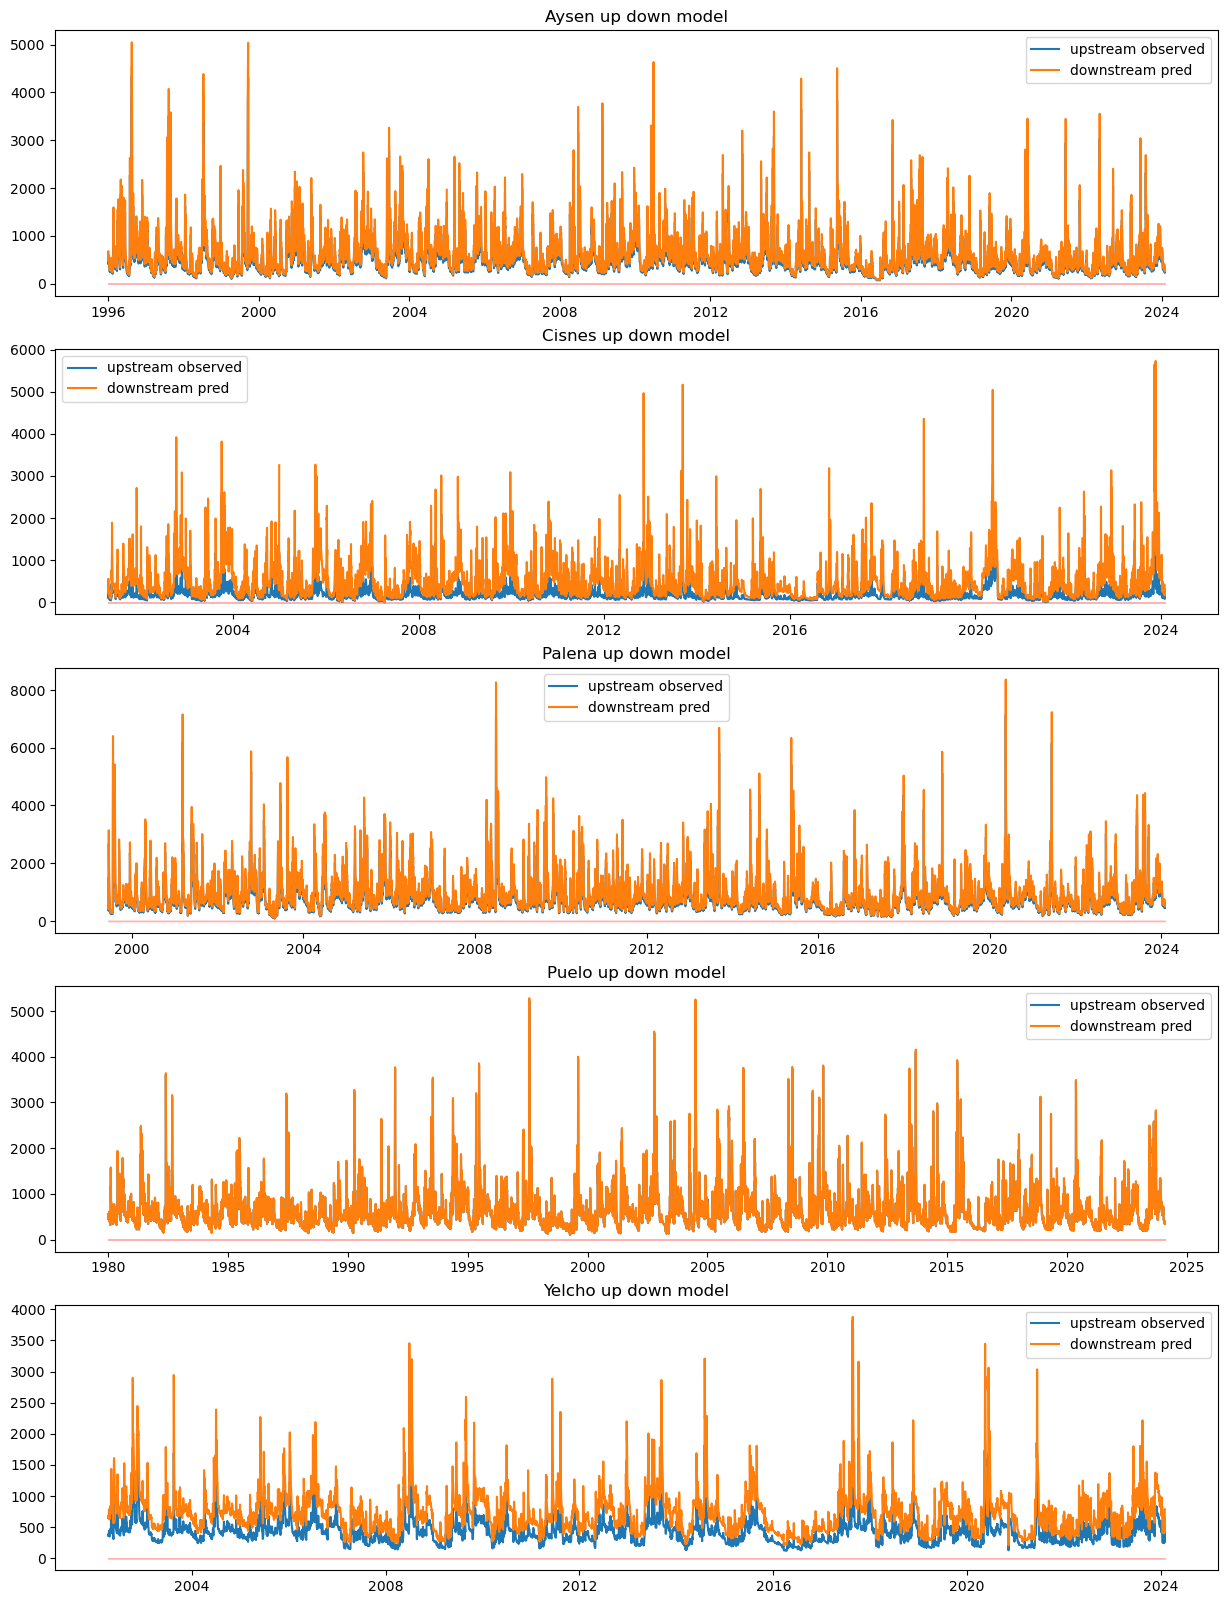

In [13]:
#up_obs["Puelo"] = float("NaN") # temporary
fig, axes = plt.subplots(figsize=(15, 4*len(rivers)), nrows=len(rivers))
for (river, ax) in zip(rivers, axes):
    uo = up_obs[river]
    dp = down_pred[river]
    ax.plot(uo, label="upstream observed")
    ax.plot(dp, label="downstream pred")
    ax.fill_between(up_obs.index, (uo>dp)*uo, alpha=0.3, color="r")
    ax.set_title(river+" up down model")
    ax.legend()
if save_est:
    fig.savefig(f"{scaling_path}/scale_vs_obs_flow.jpg")

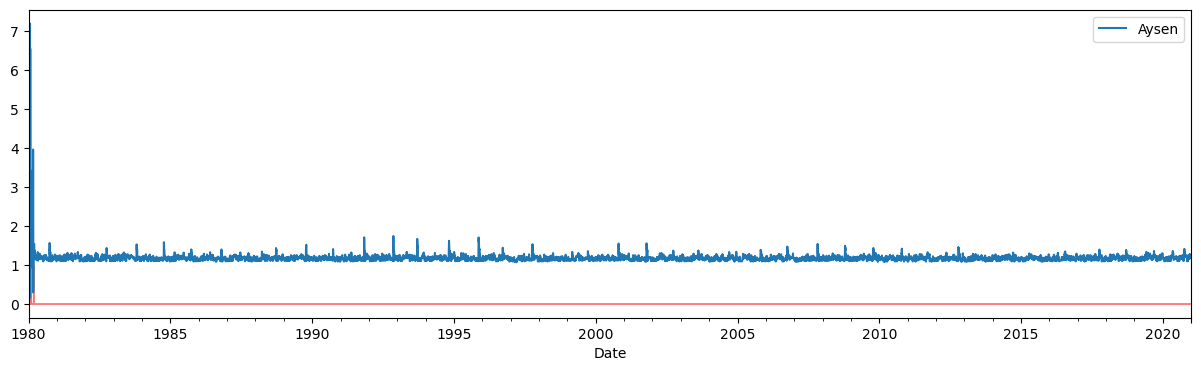

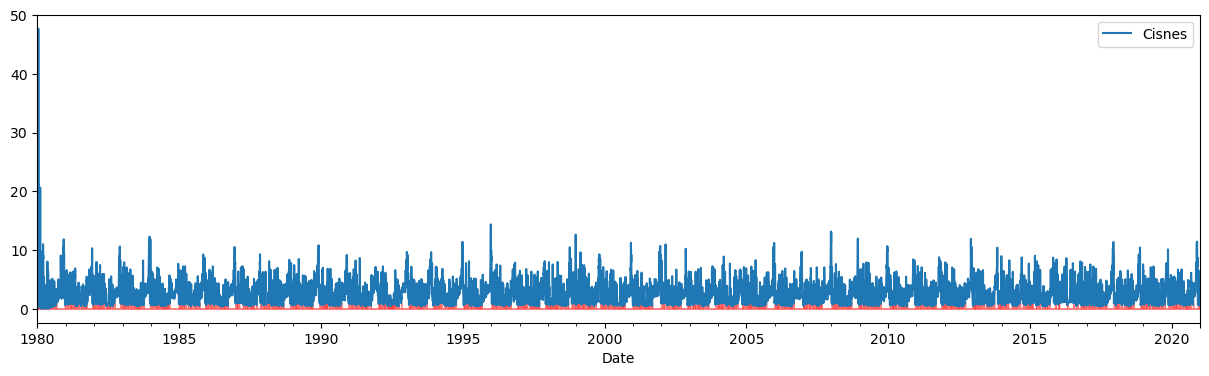

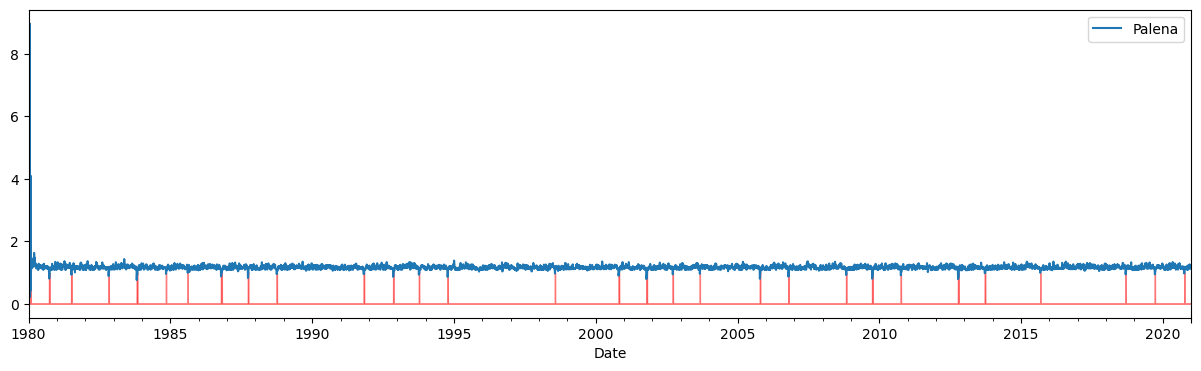

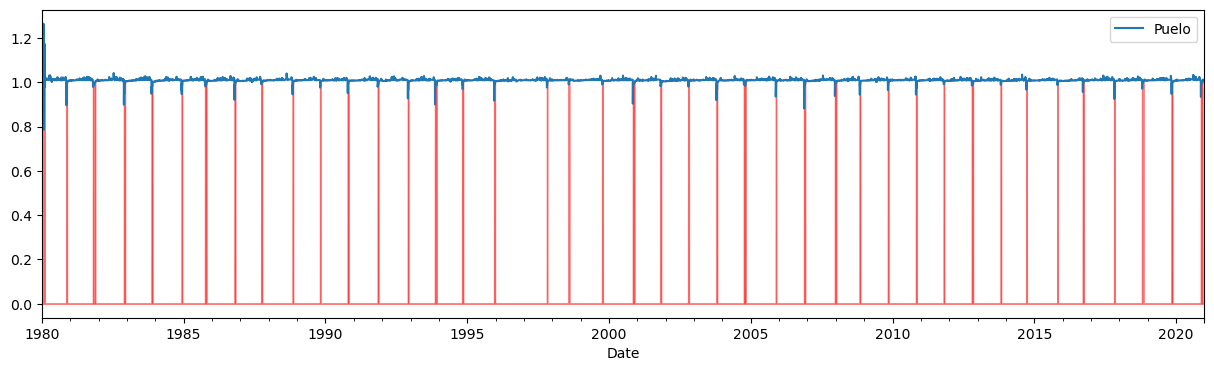

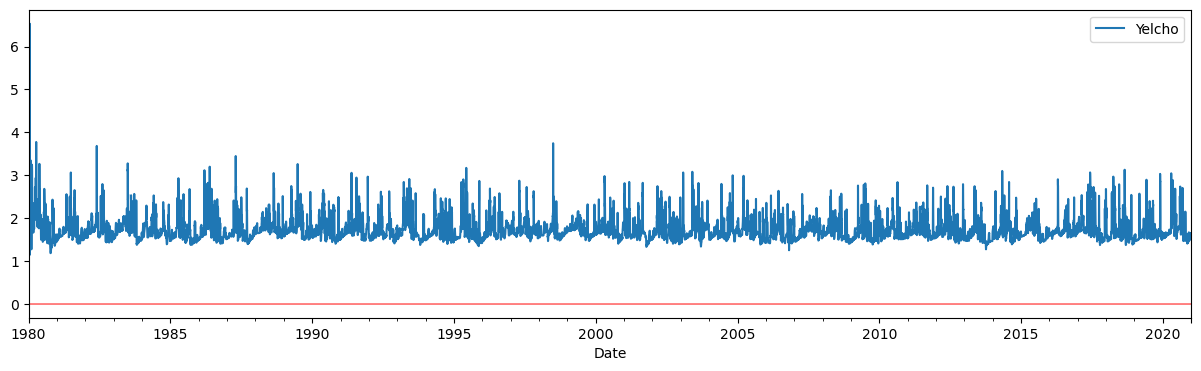

In [14]:
for r in rivers:
    ax = ratio.plot(y=[r], figsize=(15, 4))
    ax.fill_between(ratio.index, ratio[r]<1, alpha=0.5, color="r")

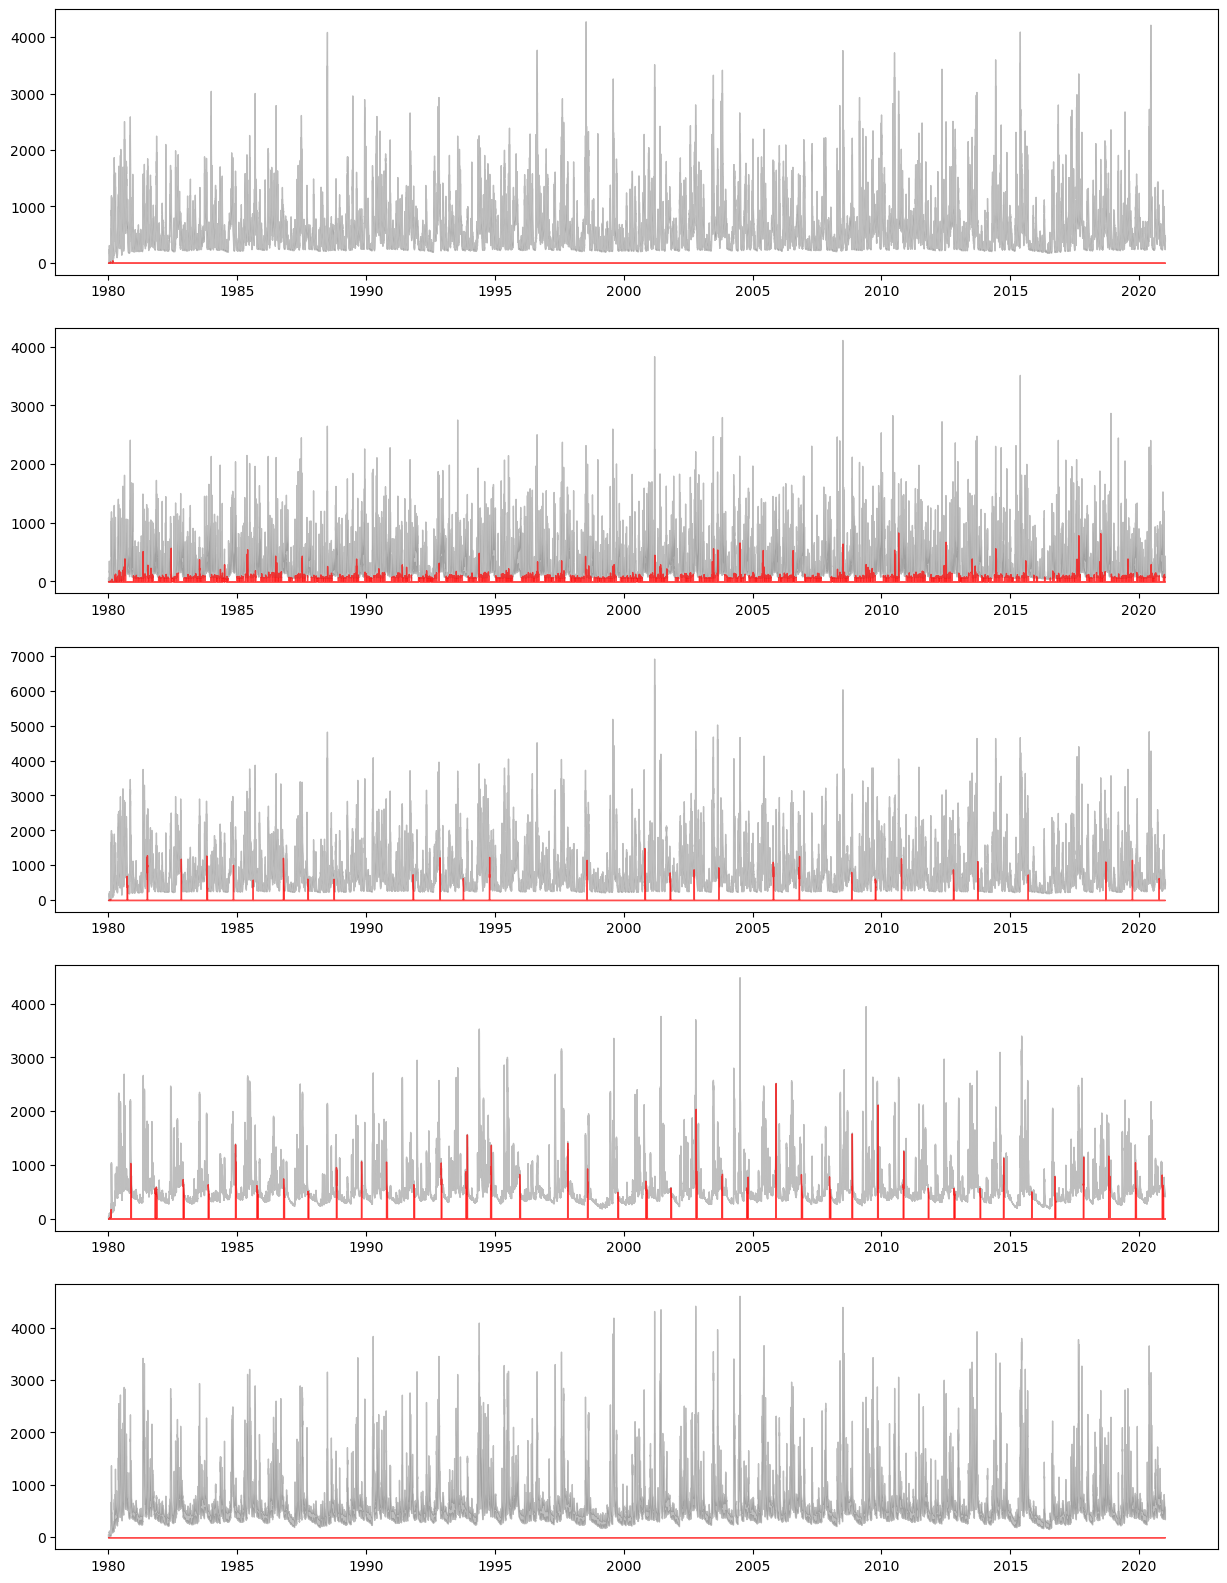

In [15]:
fig, axes = plt.subplots(figsize=(15, 4*len(rivers)), nrows=len(rivers))
for (r, ax) in zip(rivers, axes):
    ax.fill_between(downmodel.index, downmodel[r], upmodel[r],
                    color="gray", alpha=0.5)
    ax.fill_between(ratio.index, (ratio[r]<1)*downmodel[r], alpha=0.7, color="r")
if save_est:
    fig.savefig(f"{scaling_path}/scaling_validation.jpg")

In [16]:
# table of dates where the vic ratio is less than 1 for any of the rivers
ratio.where(ratio < 1).dropna(how="all")
(ratio["Cisnes"] < 1).sum() / ratio["Cisnes"].shape[0]
rcisnes = ratio["Cisnes"]
rcisnes.groupby(~(rcisnes < 1).cumsum()).count().sort_values()

Cisnes
-2311      1
-1739      1
-1738      1
-1737      1
-1736      1
        ... 
-3491    117
-3127    122
-581     124
-1810    130
-3248    133
Name: Cisnes, Length: 4618, dtype: int64

In [17]:
jul_ratio.head(5)

,Aysen,Cisnes,Palena,Puelo,Yelcho
Date,,,,,
1,1.154268,2.609241,1.163394,1.007455,1.657684
2,1.148737,2.499139,1.170907,1.007348,1.630503
3,1.147195,2.355226,1.169367,1.007382,1.623172
4,1.154861,2.380746,1.166611,1.007402,1.620210
5,1.156145,2.644946,1.173937,1.007495,1.644190


In [18]:
jul_ratio_rolling.max()

Aysen     1.178864
Cisnes    3.589072
Palena    1.176030
Puelo     1.011914
Yelcho    1.829683
dtype: float64

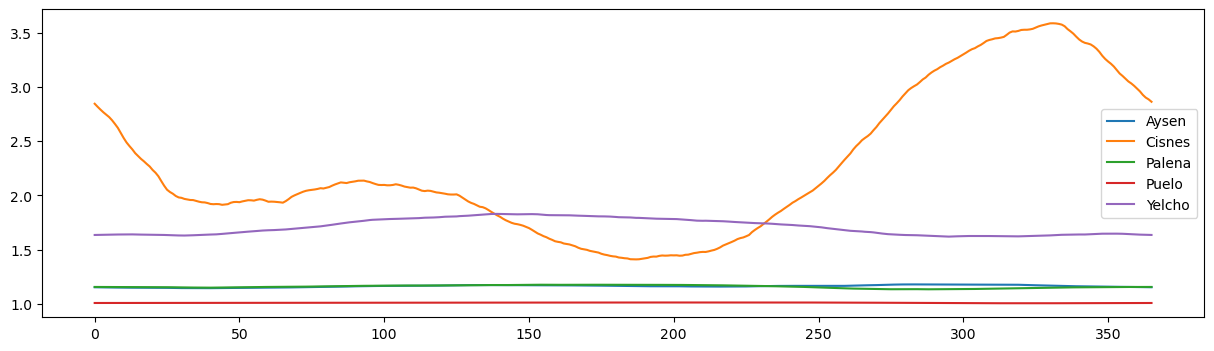

In [19]:
jul_ratio_rolling.plot(figsize=(15,4)).get_figure().savefig(f"{scaling_path}/julratio_rolling_{window_size}day_plot.jpg")

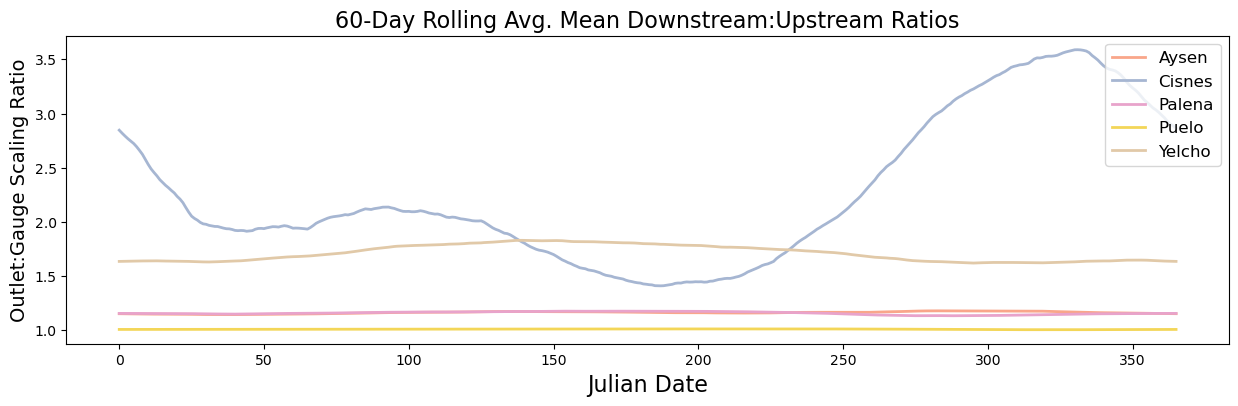

In [24]:
# Define your color map (dict of column → color)
river_colors = {
    "Puelo":   "#f3d658",
    "Yelcho":  "#e1c9a8",
    "Palena":  "#e8a3cb",
    "Cisnes":  "#a6b6d2",
    "Aysen":   "#f9a68a",
}

# Plot and grab the Axes
ax = jul_ratio_rolling.plot(
    figsize=(15, 4),
    color=[river_colors[col] for col in jul_ratio_rolling.columns],
    linewidth=2
)

# Set axis labels and a title
ax.set_xlabel("Julian Date",      fontsize=16)
ax.set_ylabel("Outlet:Gauge Scaling Ratio", fontsize=14)
ax.set_title(f"{window_size}-Day Rolling Avg. Mean Downstream:Upstream Ratios", fontsize=16)

# Optionally tweak the legend
ax.legend(title="", fontsize=12, title_fontsize=16, loc="upper right")

# Save the figure
fig = ax.get_figure()
fig.savefig(f"{scaling_path}/{window_size}day_plot.jpg", bbox_inches="tight")


In [ ]:
jul_ratio.plot(figsize=(15,4)).get_figure().savefig(f"{scaling_path}/julratio_plot.jpg")

In [ ]:
ratio.max()